# Necessary Libraries

In [121]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [122]:
end_date = datetime.now()
start_date = end_date - relativedelta(years=10)

def download_and_prepare_data(tickers, start_date, end_date, currency='USDTHB=X'):
    df = pd.DataFrame(yf.download(tickers, start=start_date, end=end_date, auto_adjust=True))
    df.dropna(inplace=True)  # Remove rows with missing data

    return df

tickers = ["GC=F", "SI=F", 'SPY', 'QQQ', 'GLD', 'SLV', 'GDX',  'TLT',  'USO', 'AAPL', 'BTC-USD', "NVDA"]

df = download_and_prepare_data(tickers, start_date, end_date)
display(df["Close"].corr())
# 1. Calculate the correlation matrix
corr_matrix = df["Close"].corr()

# 2. Flatten the matrix into a 1D list of pairs (e.g., AAPL-GLD: 0.45)
pairs = corr_matrix.unstack()

# 3. Remove self-correlations (an asset's correlation with itself is 1.0)
# We also remove duplicate pairs (A-B and B-A) by sorting the index
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]

# --- GET THE MOST NEGATIVELY CORRELATED PAIR ---
most_negative_pair = pairs.idxmin()
most_negative_value = pairs.min()

print(f"The two assets with the most negative correlation are:")
print(f"{most_negative_pair[0]} and {most_negative_pair[1]} (Correlation: {most_negative_value:.4f})\n")

# --- GET ALL PAIRS WITH NEGATIVE OR ZERO CORRELATION ---
# Filter for pairs where correlation is <= 0.5

negative_pairs = pairs[pairs <= 0.5].sort_values()
# negative_pairs = pairs.sort_values()

print("All pairs with negative or zero correlation:")
print(negative_pairs)

[*********************100%***********************]  12 of 12 completed


Ticker,AAPL,BTC-USD,GC=F,GDX,GLD,NVDA,QQQ,SI=F,SLV,SPY,TLT,USO
Ticker,,,,,,,,,,,,
AAPL,1.000000,0.875586,0.850425,0.727918,0.846313,0.845170,0.975224,0.727585,0.715522,0.974944,-0.330281,-0.326206
BTC-USD,0.875586,1.000000,0.846782,0.722158,0.843825,0.905514,0.937570,0.698430,0.688003,0.937455,-0.349802,-0.216473
GC=F,0.850425,0.846782,1.000000,0.959355,0.999898,0.931142,0.903771,0.935617,0.929800,0.906431,-0.321670,-0.181844
GDX,0.727918,0.722158,0.959355,1.000000,0.961647,0.830321,0.793264,0.966007,0.965037,0.790525,-0.173911,-0.202704
GLD,0.846313,0.843825,0.999898,0.961647,1.000000,0.929238,0.900505,0.937427,0.931967,0.902936,-0.317049,-0.182760
NVDA,0.845170,0.905514,0.931142,0.830321,0.929238,1.000000,0.909789,0.817576,0.809544,0.917627,-0.491946,-0.048337
QQQ,0.975224,0.937570,0.903771,0.793264,0.900505,0.909789,1.000000,0.782868,0.771903,0.996029,-0.312341,-0.293448
SI=F,0.727585,0.698430,0.935617,0.966007,0.937427,0.817576,0.782868,1.000000,0.999423,0.784251,-0.259593,-0.136738
SLV,0.715522,0.688003,0.929800,0.965037,0.931967,0.809544,0.771903,0.999423,1.000000,0.773164,-0.254614,-0.132842


The two assets with the most negative correlation are:
TLT and USO (Correlation: -0.5570)

All pairs with negative or zero correlation:
Ticker   Ticker
TLT      USO      -0.557002
NVDA     TLT      -0.491946
SPY      TLT      -0.362997
BTC-USD  TLT      -0.349802
AAPL     TLT      -0.330281
         USO      -0.326206
GC=F     TLT      -0.321670
GLD      TLT      -0.317049
QQQ      TLT      -0.312341
         USO      -0.293448
SI=F     TLT      -0.259593
SLV      TLT      -0.254614
SPY      USO      -0.235899
BTC-USD  USO      -0.216473
GDX      USO      -0.202704
GLD      USO      -0.182760
GC=F     USO      -0.181844
GDX      TLT      -0.173911
SI=F     USO      -0.136738
SLV      USO      -0.132842
NVDA     USO      -0.048337
dtype: float64


## Conclusion for choosing which asset
#### In this case I choose NVDA and TLT, as both assets are those I am familiar with

# Parameters

In [172]:
ASSET = ["NVDA", "TLT", "SPY", "USO"] 
ASSET_NAMES = ['NVIDIA', 'Treasury Bond', 'S&P 500', 'Oil']
MACRO_TICKERS = ['^DJI', '^SPX', '^IXIC', '^N225', 'GC=F', 'CL=F', '^TNX', 'USDTHB=X', "^VIX", "GVZ", "^OVX"]


ASSET_CONFIG = {
    'NVDA': {
        'proba_thresh' : 0.55,
        'trend_fast'   : 20,
        'trend_slow'   : 50,
        'invest_frac'  : 0.80,
        'stop_loss'    : 0.07,
    },
    'TLT': {
        'proba_thresh' : 0.52,
        'trend_fast'   : 10,
        'trend_slow'   : 30,
        'invest_frac'  : 0.80,
        'stop_loss'    : 0.04,
    },
    'SPY': {
        'proba_thresh' : 0.53,
        'trend_fast'   : 15,
        'trend_slow'   : 40,
        'invest_frac'  : 0.75,
        'stop_loss'    : 0.05,
    },
    'USO': {
        'proba_thresh' : 0.51,
        'trend_fast'   : 12,
        'trend_slow'   : 35,
        'invest_frac'  : 0.60,
        'stop_loss'    : 0.06,
    }

}
# ── Backtester Settings ──────────────────────────────────────────────────────
INITIAL_CAPITAL = 1_000_000  # THB
TRANSACTION_FEE = 0.003  # 0.3% on buy and sell
MAX_ASSET_WEIGHT = 0.75  # Max allocation per asset (portfolio constraint)
PROBA_THRESHOLD = 0.1  # Min predicted probability to act on signal
STOP_LOSS_PCT = 0.1  # Stop-loss: exit if position drops 7% from entry
REBAL_THRESHOLD  = 0.075   # only rebalance if weight drifts > 5% from target

# ── ML Settings ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
LOOKAHEAD = 5  # Predict next N days' direction

print("Configuration set.")

Configuration set.


# Data

In [173]:
def download_and_prepare_data(tickers, start_date, end_date, currency='USDTHB=X'):
    df = pd.DataFrame(yf.download(tickers, start=start_date, end=end_date, auto_adjust=True))
    df.dropna(inplace=True)  # Remove rows with missing data

    #get exchange rate data
    exr_data = yf.download(currency, start=start_date, end=end_date, auto_adjust=True)
    exr_data.dropna(inplace=True)

    # Calculate the exchange rate index (USD to THB)
    # 3. Align the exchange rate index to match the stock data index exactly.
    # 'ffill' carries the last known exchange rate forward to fill any holiday gaps.
    aligned_exr = exr_data['Close'].squeeze().reindex(df.index, method='ffill')
    print(aligned_exr.tail())  # Check the aligned exchange rate series
    print(df.tail())  # Check the original stock data before conversion

    # --- THE VECTORIZED APPROACH ---
    # 4. Define the columns we want to convert (we leave 'Volume' alone)
    price_cols = ['Open', 'High', 'Low', 'Close']
    
    # 5. Multiply all price columns by the exchange rate instantly
    # axis=0 (or axis='index') tells Pandas to match the Dates in the Series 
    # with the Dates in the DataFrame index.
    for col in price_cols:
        # df[col] selects all 5 tickers for that specific price type.
        # .mul(..., axis=0) instantly multiplies all 5 columns by the exchange rate.
        df[col] = df[col].mul(aligned_exr, axis=0)
            
    return df
df = download_and_prepare_data(ASSET, start_date, end_date)

display(df.tail())
print(df.shape)

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed

Date
2026-03-26    32.770000
2026-03-27    32.959999
2026-03-30    32.959999
2026-03-31    32.849998
2026-04-01    32.509998
Name: USDTHB=X, dtype: float64
Price            Close                                           High  \
Ticker            NVDA         SPY        TLT         USO        NVDA   
Date                                                                    
2026-03-26  171.240005  645.090027  86.110001  117.260002  176.509995   
2026-03-27  167.520004  634.090027  85.639999  124.199997  170.970001   
2026-03-30  165.169998  631.969971  86.779999  129.830002  169.449997   
2026-03-31  174.399994  650.340027  86.690002  127.250000  174.619995   
2026-04-01  175.750000  655.239990  86.260002  124.089996  177.369995   

Price                                                 Low              \
Ticker             SPY        TLT         USO        NVDA         SPY   
Date                                                                    
2026-03-26  654.849976  86.610001  118.9

Price             Close                                                 High  \
Ticker             NVDA           SPY          TLT          USO         NVDA   
Date                                                                           
2026-03-26  5611.535058  21139.600475  2821.824759  3842.610324  5784.232601   
2026-03-27  5521.459187  20899.606705  2822.694301  4093.631786  5635.171084   
2026-03-30  5444.002988  20829.729656  2860.268680  4279.196741  5585.071744   
2026-03-31  5729.039533  21363.668890  2847.766448  4180.162306  5736.266573   
2026-04-01  5713.632205  21301.850983  2804.312525  4034.165573  5766.298244   

Price                                                       Low                \
Ticker               SPY          TLT          USO         NVDA           SPY   
Date                                                                            
2026-03-26  21459.434000  2838.209760  3897.663934  5608.257858  21130.751935   
2026-03-27  21182.072126  2837.855871  4129.887986  5504.649266  20867.304538   
2026-03-30  21106.594453  2865.871820  4287.436741  5414.339190  20741.069190   
2026-03-31  21403.087284  2863.205987  4301.050060  5484.635966  20957.641385   
2026-04-01  21408.484730  2818.941925  4087.482198  5681.122207  21229.028904   

Price                                        Open                             \
Ticker              TLT          USO         NVDA           SPY          TLT   
Date                                                                           
2026-03-26  2815.926149  3775.103953  5769.814221  21368.006418  2829.361720   
2026-03-27  2816.431821  3970.691130  5603.199844  21176.799412  2818.079922   
2026-03-30  2850.710250  4163.177404  5562.988605  21098.024531  2855.324630   
2026-03-31  2843.824358  4079.969710  5484.964285  20989.178105  2855.650377   
2026-04-01  2803.337264  3981.824704  5721.759705  21258.288696  2804.962615   

Price                       Volume                                 
Ticker              USO       NVDA        SPY       TLT       USO  
Date                                                               
2026-03-26  3825.242263  186152200   96494400  39537000  42398600  
2026-03-27  3981.238320  196212700  103649400  39928900  32843700  
2026-03-30  4180.646163  185627000   99275900  36473200  40484900  
2026-03-31  4249.147503  226181300  152534100  47112200  58856900  
2026-04-01  4059.198410  167630300   97734200  31128700  45079600

(2514, 20)


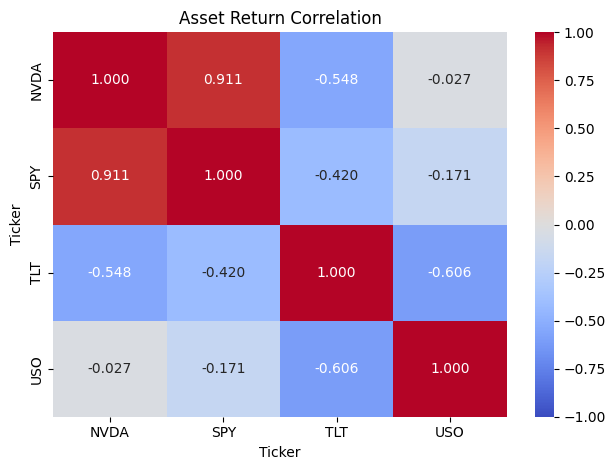

In [174]:
correlation = df['Close'].corr()
correlation

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f')
plt.title('Asset Return Correlation')
plt.tight_layout()
plt.show()

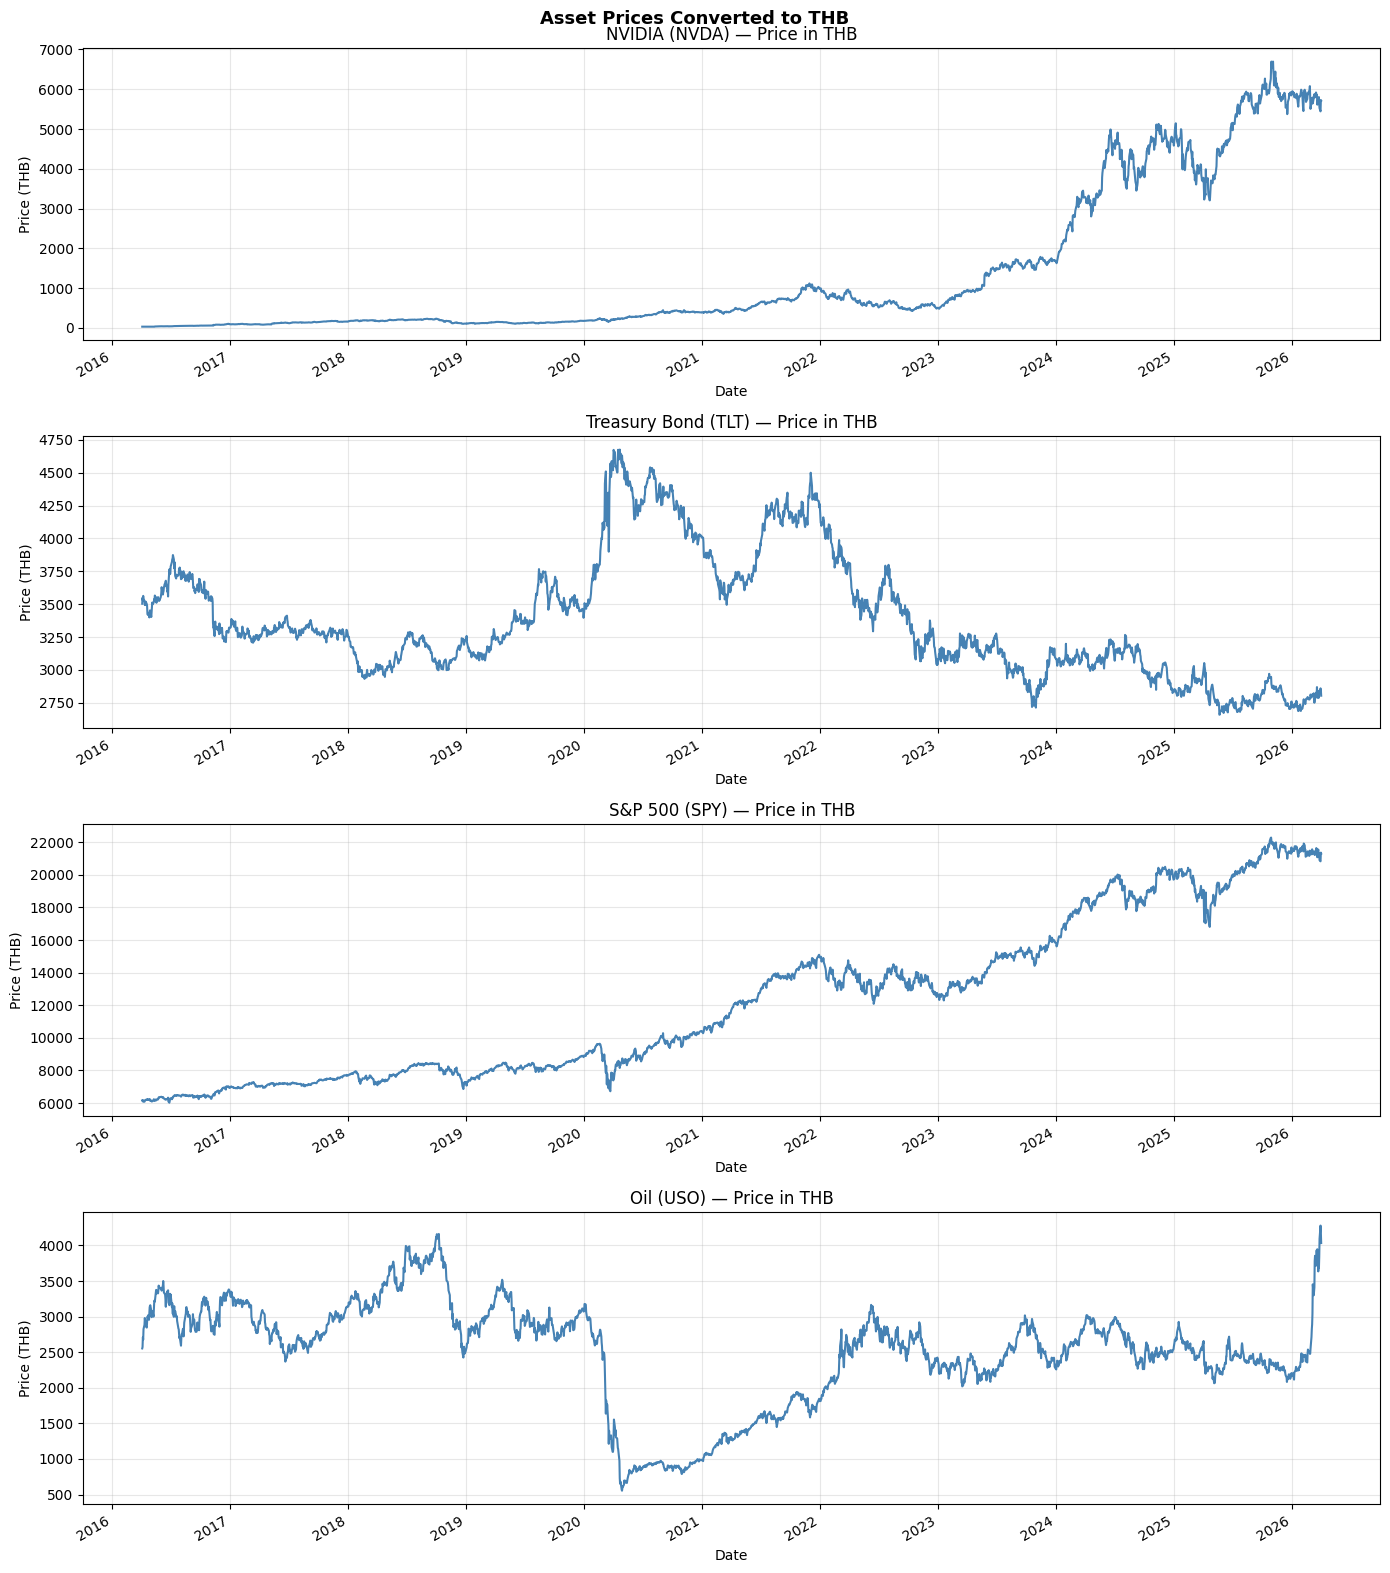

In [175]:
num_assets = len(ASSET)

# Dynamically set the number of columns (num_assets) and adjust the figure width (7 * num_assets)
fig, axes = plt.subplots(num_assets, 1, figsize=(14, 4 * num_assets))

# If there is only 1 asset, matplotlib returns a single axis object instead of an array.
# We wrap it in a list so the zip() loop doesn't break.
if num_assets == 1:
    axes = [axes]
    
for ax, ticker, name in zip(axes, ASSET, ASSET_NAMES):
    df["Close"][ticker].plot(ax=ax, color='steelblue')
    ax.set_title(f'{name} ({ticker}) — Price in THB')
    ax.set_ylabel('Price (THB)')
    ax.grid(alpha=0.3)
plt.suptitle('Asset Prices Converted to THB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Features

In [176]:
# ── Download macro data (separate from your main df) ─────────────────────────
from fileinput import close


def download_macro(start_date, end_date):
    """
    Download macro indicators. These are NOT converted to THB —
    we only use their returns/changes as features, not prices.
    """
    raw = yf.download(MACRO_TICKERS, start=start_date, end=end_date,
                      auto_adjust=True, progress=False)
    close = raw['Close'].copy()
    close = close.ffill()
    return close

def build_features(ticker: str, df: pd.DataFrame, macro_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the full feature matrix for one asset.
 
    Parameters
    ----------
    ticker    : e.g. 'NVDA'
    df        : your existing df (THB-converted, MultiIndex columns)
    macro_df  : raw macro close prices (not THB converted)
 
    Returns
    -------
    DataFrame with all features + 'label' column, NaNs dropped
    """
    # ── Pull OHLCV for this ticker ────────────────────────────────────────
    close  = df['Close'][ticker]
    high   = df['High'][ticker]
    low    = df['Low'][ticker]
    volume = df['Volume'][ticker]
 
    feat = pd.DataFrame(index=close.index)
 
    # ══════════════════════════════════════════════════════════════════════
    # BLOCK 1 — pandas-ta Technical Indicators (asset's own price)
    # ══════════════════════════════════════════════════════════════════════
 
    # Trend
    feat['rsi_14']         = ta.rsi(close, length=14)
    feat['ema_20']         = ta.ema(close, length=20)
    feat['ema_50']         = ta.ema(close, length=50)
    feat['price_vs_ema20'] = (close / feat['ema_20']) - 1
 
    # MACD (version-safe column lookup)
    macd        = ta.macd(close)
    macd_line   = [c for c in macd.columns if c.startswith('MACD_')][0]
    macd_signal = [c for c in macd.columns if c.startswith('MACDs_')][0]
    macd_hist   = [c for c in macd.columns if c.startswith('MACDh_')][0]
    feat['macd']        = macd[macd_line]
    feat['macd_signal'] = macd[macd_signal]
    feat['macd_hist']   = macd[macd_hist]
 
    # Bollinger Bands (version-safe column lookup)
    bb        = ta.bbands(close, length=20)
    bb_lower  = [c for c in bb.columns if c.startswith('BBL')][0]
    bb_upper  = [c for c in bb.columns if c.startswith('BBU')][0]
    bb_middle = [c for c in bb.columns if c.startswith('BBM')][0]
    feat['bb_pct']   = (close - bb[bb_lower]) / (bb[bb_upper] - bb[bb_lower])
    feat['bb_width'] = (bb[bb_upper] - bb[bb_lower]) / bb[bb_middle]
 
    # ADX (version-safe column lookup)
    adx     = ta.adx(high, low, close, length=14)
    adx_col = [c for c in adx.columns if c.startswith('ADX_')][0]
    feat['adx_14'] = adx[adx_col]
 
    # Volatility & Momentum
    feat['atr_14'] = ta.atr(high, low, close, length=14)
    feat['mom_10'] = ta.mom(close, length=10)
 
    # Volume
    feat['volume_ratio'] = volume / volume.rolling(20).mean()
 
    # Lag returns
    ret = close.pct_change()
    for lag in [1, 2, 3, 5, 10]:
        feat[f'ret_lag{lag}'] = ret.shift(lag)
 
    # Rolling volatility
    feat['vol_10'] = ret.rolling(10).std()
    feat['vol_20'] = ret.rolling(20).std()
    #implied volatility
    feat["Return"] = ret
 
    # ══════════════════════════════════════════════════════════════════════
    # BLOCK 2 — Macro Features (external signals)
    # ══════════════════════════════════════════════════════════════════════
    macro = macro_df.reindex(close.index, method='ffill')
 
    feat['dji_ret']       = macro['^DJI'].pct_change()
    feat['spx_ret']       = macro['^SPX'].pct_change()
    feat['nasdaq_ret']    = macro['^IXIC'].pct_change()
    feat['n225_ret']      = macro['^N225'].pct_change()
    feat['gold_ret']      = macro['GC=F'].pct_change()
    feat['oil_ret']       = macro['CL=F'].pct_change()
    feat['yield_10y']     = macro['^TNX']
    feat['yield_10y_chg'] = macro['^TNX'].diff()
    feat['fx_chg']        = macro['USDTHB=X'].pct_change()

    #   Implied Volatility Proxies 
    iv  = macro_df['^VIX'].reindex(feat.index, method='ffill') #use vix as iv proxy

    feat['iv_level']     = iv
    feat['iv_chg_1d']    = iv.pct_change(1)
    feat['iv_chg_5d']    = iv.pct_change(5)
    feat['iv_vs_ma20']   = (iv / iv.rolling(20).mean()) - 1   # elevated vs normal?
    feat['iv_regime']    = (iv > 20).astype(int)              # 1 = fear, 0 = calm

    # IV vs Historical Volatility spread (volatility risk premium)
    ret = close.pct_change()
    hv_20 = ret.rolling(20).std() * np.sqrt(252) * 100       # annualize to match VIX scale
    feat['iv_hv_spread'] = iv - hv_20                         # >0 means options are "expensive"
    feat['iv_hv_ratio']  = iv / hv_20.replace(0, np.nan)     # ratio form
 
    # ══════════════════════════════════════════════════════════════════════
    # BLOCK 3 — Target Label
    # ══════════════════════════════════════════════════════════════════════
    future_ret    = ret.shift(-LOOKAHEAD)
    forward_10d = ret.rolling(10).mean().shift(-10)
    feat['label'] = (forward_10d > 0).astype(float).where(future_ret.notna())

    # ══════════════════════════════════════════════════════════════════════
    # BLOCK 4 — transform CLose to log returns
    # ══════════════════════════════════════════════════════════════════════
    feat['log_ret'] = np.log(1 + ret)

    return feat.dropna()
 
 
macro_df = download_macro(start_date, end_date)
features = {ticker: build_features(ticker, df, macro_df) for ticker in ASSET}
 
for ticker in ASSET:
    f = features[ticker]
    print(f'{ticker}: {len(f)} rows × {len(f.columns)-1} features | '
          f'label balance: {f["label"].mean():.1%} Up days')

$GVZ: possibly delisted; no price data found  (1d 2016-04-02 10:40:13.523384 -> 2026-04-02 10:40:13.523384)

1 Failed download:
['GVZ']: possibly delisted; no price data found  (1d 2016-04-02 10:40:13.523384 -> 2026-04-02 10:40:13.523384)


NVDA: 2460 rows × 38 features | label balance: 63.3% Up days
TLT: 2460 rows × 38 features | label balance: 48.3% Up days
SPY: 2460 rows × 38 features | label balance: 64.4% Up days
USO: 2460 rows × 38 features | label balance: 56.9% Up days


In [177]:
print(features["NVDA"].tail())

               rsi_14       ema_20       ema_50  price_vs_ema20       macd  \
Date                                                                         
2026-03-19  51.684512  5822.828531  5821.467165        0.005829  12.905977   
2026-03-20  42.325841  5802.821043  5813.282174       -0.032755  -5.601724   
2026-03-23  48.966080  5800.225705  5811.803265       -0.004251  -7.049724   
2026-03-24  45.586967  5788.607245  5806.565172       -0.019068 -15.868723   
2026-03-25  50.275861  5789.857944  5806.375933        0.002052 -12.744889   

            macd_signal  macd_hist    bb_pct  bb_width     adx_14  ...  \
Date                                                               ...   
2026-03-19     2.802248  10.103728  0.574421  0.090531  10.526542  ...   
2026-03-20     1.121454  -6.723178  0.154148  0.094547  11.138690  ...   
2026-03-23    -0.512782  -6.536943  0.466168  0.091415  11.191926  ...   
2026-03-24    -3.583970 -12.284753  0.303220  0.088428  11.802727  ...   
2026-03-2

# First Period Testing PLUS adding strategy

## Split data then train

In [178]:
def process_and_split(ticker, df, features_dict, train_pct=0.70, val_pct=0.15):
    """
    Merges original price data with features, fills gaps, and splits chronologically.
    """
    print(f"\n--- Processing {ticker} ---")
    
    # 1. EXTRACT ORIGINAL PRICES (Keeps all original dates)
    # .xs() pulls the specific ticker out of your MultiIndex DataFrame
    price_df = df.xs(ticker, level=1, axis=1)[['Close', 'Volume']]
    
    # 2. GET FEATURES 
    feat_df = features_dict[ticker]
    
    # 3. MERGE THEM (Left Join)
    # This aligns features to the price data. The first ~50 days of features will become NaN again.
    merged_df = price_df.join(feat_df, how='left')
    
    # 4. FILL THE GAPS
    # .bfill() copies the first valid indicator backward to fill the initial warm-up period.
    # .ffill() covers any accidental gaps at the end of the dataset.
    merged_df = merged_df.dropna()
    
    # 5. SPLIT THE DATA
    X = merged_df.drop(columns=['label'])
    y = merged_df['label']
    
    n = len(merged_df)
    train_end = int(n * train_pct)
    val_end = int(n * (train_pct + val_pct))
    
    # Train Set (Oldest 70%)
    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]
    
    # Validation Set (Middle 15%)
    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]
    
    # Test Set (Newest 15%)
    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]
    
    print(f"Original Price Shape: {price_df.shape}")
    print(f"Merged & Filled Shape: {merged_df.shape}")
    print(f"Split -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'full_data': merged_df # In case you want to view the whole merged table
    }

# --- Apply to all your assets ---
data_splits = {}

trainpct = 0.7
valpct = 0.15

for ticker in ASSET: # Example: ASSET = ["NVDA", "TLT"]
    data_splits[ticker] = process_and_split(ticker, df, features, train_pct=trainpct, val_pct=valpct)

# Sanity check: view the first few rows of NVDA's training data
print("\nPreview of NVDA X_train (No NaNs!):")
print(data_splits.keys())
print(data_splits[ASSET[0]]["X_train"].tail())


--- Processing NVDA ---
Original Price Shape: (2514, 2)
Merged & Filled Shape: (2460, 41)
Split -> Train: 1722 | Val: 369 | Test: 369

--- Processing TLT ---
Original Price Shape: (2514, 2)
Merged & Filled Shape: (2460, 41)
Split -> Train: 1722 | Val: 369 | Test: 369

--- Processing SPY ---
Original Price Shape: (2514, 2)
Merged & Filled Shape: (2460, 41)
Split -> Train: 1722 | Val: 369 | Test: 369

--- Processing USO ---
Original Price Shape: (2514, 2)
Merged & Filled Shape: (2460, 41)
Split -> Train: 1722 | Val: 369 | Test: 369

Preview of NVDA X_train (No NaNs!):
dict_keys(['NVDA', 'TLT', 'SPY', 'USO'])
                 Close     Volume     rsi_14      ema_20      ema_50  \
Date                                                                   
2023-04-10  941.540949  395279000  64.518510  899.481879  818.651985   
2023-04-11  932.701184  314378000  61.948893  902.645622  823.124502   
2023-04-12  907.180618  446259000  55.123116  903.077526  826.420820   
2023-04-13  902.171944  3

# ML Model

Two models are trained per asset:
- **Model 1 — Random Forest**: stable, low-variance, good for noisy financial data
- **Model 2 — XGBoost**: captures non-linear patterns, faster to adapt to trends

Both are trained on the **train set**, tuned on the **val set**, and evaluated on the **test set** only at the end.

In [179]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import xgboost as xgb
import numpy as np


In [180]:
def train_models(ticker: str, data_splits: dict) -> dict:
    """
    Train Random Forest and XGBoost on the train split.
    Evaluate on the val split to confirm no overfitting.
    Returns fitted pipelines ready for prediction.
    """
    X_train = data_splits[ticker]['X_train']
    y_train = data_splits[ticker]['y_train']
    X_val   = data_splits[ticker]['X_val']
    y_val   = data_splits[ticker]['y_val']

    # ── Model 1: Random Forest ────────────────────────────────────────────
    rf_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=3,
            min_samples_leaf=20,
            class_weight='balanced',   # handles class imbalance
            random_state=RANDOM_STATE
        ))
    ])
    rf_pipe.fit(X_train, y_train)

    # ── Model 2: XGBoost ─────────────────────────────────────────────────
    xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ])
    xgb_pipe.fit(X_train, y_train)

    # ── Validation report ────────────────────────────────────────────────
    print(f'\n=== {ticker} — Validation Set Report ===')
    for name, pipe in [('Random Forest', rf_pipe), ('XGBoost', xgb_pipe)]:
        y_pred = pipe.predict(X_val)
        print(f'\n  [{name}]')
        print(classification_report(y_val, y_pred,
                                    target_names=['Down/Flat', 'Up'],
                                    zero_division=0))

    return {'rf': rf_pipe, 'xgb': xgb_pipe}


# Train for all assets
models = {ticker: train_models(ticker, data_splits) for ticker in ASSET}


=== NVDA — Validation Set Report ===

  [Random Forest]
              precision    recall  f1-score   support

   Down/Flat       0.31      1.00      0.47       114
          Up       0.00      0.00      0.00       255

    accuracy                           0.31       369
   macro avg       0.15      0.50      0.24       369
weighted avg       0.10      0.31      0.15       369


  [XGBoost]
              precision    recall  f1-score   support

   Down/Flat       0.31      0.79      0.44       114
          Up       0.68      0.20      0.31       255

    accuracy                           0.38       369
   macro avg       0.49      0.49      0.38       369
weighted avg       0.56      0.38      0.35       369


=== TLT — Validation Set Report ===

  [Random Forest]
              precision    recall  f1-score   support

   Down/Flat       0.67      0.16      0.26       196
          Up       0.49      0.91      0.64       173

    accuracy                           0.51       369
  

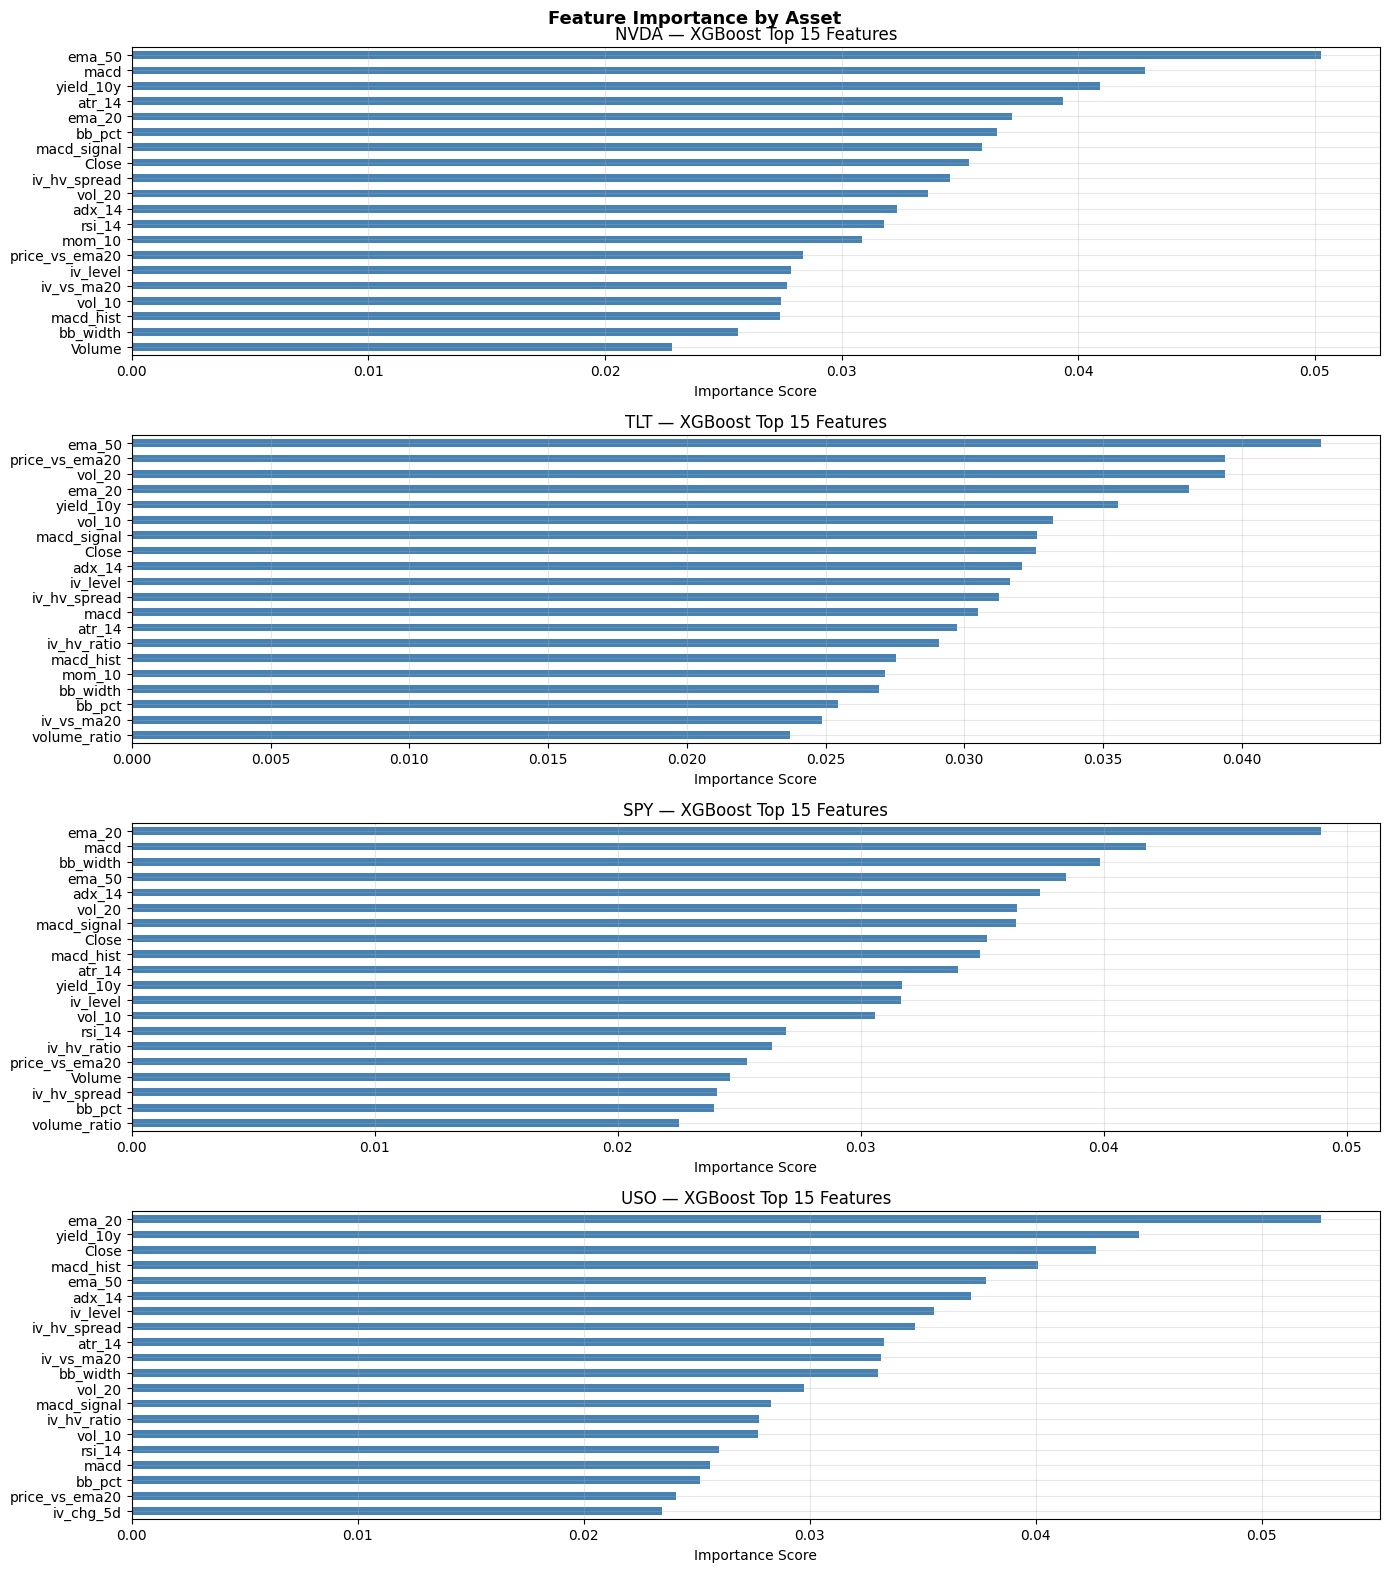

In [181]:
num_assets = len(ASSET)

# Set rows = num_assets, columns = 1. Adjust figure height dynamically.
fig, axes = plt.subplots(num_assets, 1, figsize=(14, 4 * num_assets))

if num_assets == 1:
    axes = [axes]

for ax, ticker in zip(axes, ASSET):
    xgb_clf   = models[ticker]['xgb'].named_steps['clf']
    feat_cols = data_splits[ticker]['X_train'].columns.tolist()
    importance = pd.Series(xgb_clf.feature_importances_, index=feat_cols)
    importance.nlargest(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{ticker} — XGBoost Top 15 Features')
    ax.set_xlabel('Importance Score')
    ax.grid(alpha=0.3)

plt.suptitle('Feature Importance by Asset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Strategy

In [182]:
def compute_target_weights(proba_dict: dict) -> dict:
    """
    Convert per-asset ML confidence scores into target portfolio weights.

    Parameters
    ----------
    proba_dict : {ticker: avg_proba}  e.g. {'NVDA': 0.63, 'TLT': 0.48}

    Returns
    -------
    weights : {ticker: weight, ..., 'cash': weight}  — sums to 1.0
    """
    # Zero out assets below conviction threshold
    confident = {t: p for t, p in proba_dict.items() if p >= PROBA_THRESHOLD}

    if not confident:
        # No conviction on any asset → full cash
        return {t: 0.0 for t in proba_dict} | {'cash': 1.0}

    total_conf = sum(confident.values())

    # Proportional allocation, capped by MAX_WEIGHT
    raw_weights = {t: min(p / total_conf, MAX_ASSET_WEIGHT) for t, p in confident.items()}

    # Renormalize after cap
    total_w = sum(raw_weights.values())
    norm_weights = {t: w / total_w for t, w in raw_weights.items()}

    # Assets with no confidence get 0
    weights = {t: norm_weights.get(t, 0.0) for t in proba_dict}

    # Scale down to leave some cash buffer (invest proportional to avg confidence)
    avg_conf = sum(confident.values()) / len(proba_dict)  # penalizes partial conviction
    invest_ratio = min(avg_conf / PROBA_THRESHOLD, 1.0)       # scale: 0.55→ full invest
    weights = {t: w * invest_ratio for t, w in weights.items()}

    weights['cash'] = max(0.0, 1.0 - sum(weights.values()))
    return weights


def should_rebalance(current_w: dict, target_w: dict) -> bool:
    """
    Return True only if any asset weight drifts more than REBAL_THRESH from target.
    Avoids unnecessary trading and fee drag.
    """
    for ticker in ASSET:
        if abs(current_w.get(ticker, 0.0) - target_w.get(ticker, 0.0)) > REBAL_THRESHOLD:
            return True
    return False


print('Strategy functions defined.')

Strategy functions defined.


In [183]:
def run_backtest(models: dict, data_splits: dict, split: str = 'test') -> pd.DataFrame:
    """
    Run the ML-guided dynamic allocation strategy.

    Parameters
    ----------
    models      : {ticker: {'rf': pipe, 'xgb': pipe}}
    data_splits : output of process_and_split()
    split       : 'val' or 'test' — which period to backtest on

    Returns
    -------
    portfolio_df : daily records of portfolio value and positions
    """
    # ── Align test data across assets ────────────────────────────────────
    X_split = {t: data_splits[t][f'X_{split}'] for t in ASSET}
    dates   = X_split[ASSET[0]].index  # use first asset's index as reference

    # ── Pre-generate all ML probabilities ────────────────────────────────
    # Do this outside the loop for speed
    probas = {}
    for ticker in ASSET:
        rf_p  = models[ticker]['rf'].predict_proba(X_split[ticker])[:, 1]
        xgb_p = models[ticker]['xgb'].predict_proba(X_split[ticker])[:, 1]
        avg_p = (rf_p + xgb_p) / 2
        probas[ticker] = pd.Series(avg_p, index=X_split[ticker].index)

    # ── Portfolio state ───────────────────────────────────────────────────
    cash     = INITIAL_CAPITAL
    shares   = {t: 0.0 for t in ASSET}   # units held
    entry_px = {t: None for t in ASSET}  # price at which we entered

    records = []

    for date in dates:
        # ── Get today's close prices (THB) ────────────────────────────────
        px = {t: data_splits[t][f'X_{split}'].loc[date, 'Close'] for t in ASSET}

        # ── Step 1: Stop-Loss Check ───────────────────────────────────────
        for ticker in ASSET:
            if shares[ticker] > 0 and entry_px[ticker] is not None:
                loss = (px[ticker] - entry_px[ticker]) / entry_px[ticker]
                if loss < - STOP_LOSS_PCT:
                    proceeds      = shares[ticker] * px[ticker]
                    cash         += proceeds * (1 - TRANSACTION_FEE)
                    shares[ticker]   = 0.0
                    entry_px[ticker] = None

        # ── Step 2: Current portfolio value and weights ───────────────────
        equity     = {t: shares[t] * px[t] for t in ASSET}
        total      = cash + sum(equity.values())
        current_w  = {t: equity[t] / total for t in ASSET}
        current_w['cash'] = cash / total

        # ── Step 3: Compute target weights from ML signals ────────────────
        proba_today = {t: probas[t].loc[date] if date in probas[t].index else 0.0
                       for t in ASSET}
        target_w    = compute_target_weights(proba_today)

        # ── Step 4: Rebalance only if drift exceeds threshold ─────────────
        if should_rebalance(current_w, target_w):

            # Sell assets that need to decrease first (frees up cash)
            for ticker in ASSET:
                target_val  = total * target_w.get(ticker, 0.0)
                current_val = equity[ticker]
                if current_val > target_val:  # need to sell
                    sell_val      = current_val - target_val
                    sell_shares   = sell_val / px[ticker]
                    shares[ticker]   -= sell_shares
                    cash             += sell_val * (1 - TRANSACTION_FEE)
                    if shares[ticker] < 1e-6:  # effectively zero
                        shares[ticker]   = 0.0
                        entry_px[ticker] = None

            # Buy assets that need to increase
            for ticker in ASSET:
                target_val  = total * target_w.get(ticker, 0.0)
                current_val = shares[ticker] * px[ticker]
                if target_val > current_val:  # need to buy
                    buy_val       = min(target_val - current_val, cash)  # can't exceed cash
                    buy_val_net   = buy_val * (1 - TRANSACTION_FEE)
                    shares[ticker]  += buy_val_net / px[ticker]
                    cash            -= buy_val
                    if entry_px[ticker] is None:  # record entry price
                        entry_px[ticker] = px[ticker]

        # ── Step 5: Record end-of-day state ──────────────────────────────
        equity_end = {t: shares[t] * px[t] for t in ASSET}
        total_end  = cash + sum(equity_end.values())

        row = {'date': date, 'total': total_end, 'cash': cash}
        for t in ASSET:
            row[f'shares_{t}']  = shares[t]
            row[f'value_{t}']   = equity_end[t]
            row[f'weight_{t}']  = equity_end[t] / total_end
            row[f'proba_{t}']   = proba_today[t]
        records.append(row)

    return pd.DataFrame(records).set_index('date')


print('Backtester defined.')

Backtester defined.


In [184]:
def run_buy_and_hold(data_splits: dict, split: str = 'test') -> pd.DataFrame:
    """
    Baseline: buy equal amounts of each asset on day 1, hold until the end.
    0.3% fee on initial buy and final sell.
    """
    # Use first asset's index for dates
    dates = data_splits[ASSET[0]][f'X_{split}'].index

    alloc   = INITIAL_CAPITAL / len(ASSET)
    shares_bh = {}
    for ticker in ASSET:
        px0 = data_splits[ticker][f'X_{split}'].iloc[0]['Close']
        shares_bh[ticker] = (alloc * (1 - TRANSACTION_FEE)) / px0  # fee on entry

    records = []
    for date in dates:
        total = sum(
            shares_bh[t] * data_splits[t][f'X_{split}'].loc[date, 'Close']
            for t in ASSET
        )
        records.append({'date': date, 'total': total})

    bh = pd.DataFrame(records).set_index('date')

    # Apply sell fee on exit
    bh.iloc[-1, bh.columns.get_loc('total')] *= (1 - TRANSACTION_FEE)
    return bh


# ── Run both strategies ──────────────────────────────────────────────────────
print('Running backtests...')
port_ml = run_backtest(models, data_splits, split='test')
port_bh = run_buy_and_hold(data_splits, split='test')

print(f'\nML Strategy  — Final value: THB {port_ml["total"].iloc[-1]:,.0f}')
print(f'Buy & Hold   — Final value: THB {port_bh["total"].iloc[-1]:,.0f}')

Running backtests...

ML Strategy  — Final value: THB 1,242,954
Buy & Hold   — Final value: THB 1,247,288


In [185]:
def compute_metrics(total_series: pd.Series, label: str) -> dict:
    """Compute key performance metrics from daily portfolio value series."""
    ret        = total_series.pct_change().dropna()
    cum_ret    = (total_series.iloc[-1] / total_series.iloc[0]) - 1
    n_days     = len(total_series)
    ann_ret    = (1 + cum_ret) ** (252 / n_days) - 1
    ann_vol    = ret.std() * np.sqrt(252)
    sharpe     = ann_ret / ann_vol if ann_vol > 0 else np.nan
    roll_max   = total_series.cummax()
    max_dd     = ((total_series - roll_max) / roll_max).min()
    calmar     = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy'         : label,
        'Cumulative Return': f'{cum_ret:.2%}',
        'Annualised Return': f'{ann_ret:.2%}',
        'Annualised Vol'   : f'{ann_vol:.2%}',
        'Sharpe Ratio'     : f'{sharpe:.3f}',
        'Max Drawdown'     : f'{max_dd:.2%}',
        'Calmar Ratio'     : f'{calmar:.3f}',
        'Final Value (THB)': f'{total_series.iloc[-1]:,.0f}'
    }


metrics_df = pd.DataFrame([
    compute_metrics(port_ml['total'], 'ML Strategy (Test)'),
    compute_metrics(port_bh['total'], 'Buy & Hold  (Test)'),
]).set_index('Strategy')

print('\n=== Performance Comparison ===')
print(metrics_df.to_string())


=== Performance Comparison ===
                   Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Calmar Ratio Final Value (THB)
Strategy                                                                                                                      
ML Strategy (Test)            24.67%            16.25%         19.04%        0.854      -13.44%        1.209         1,242,954
Buy & Hold  (Test)            25.10%            16.53%         21.01%        0.787      -19.78%        0.836         1,247,288


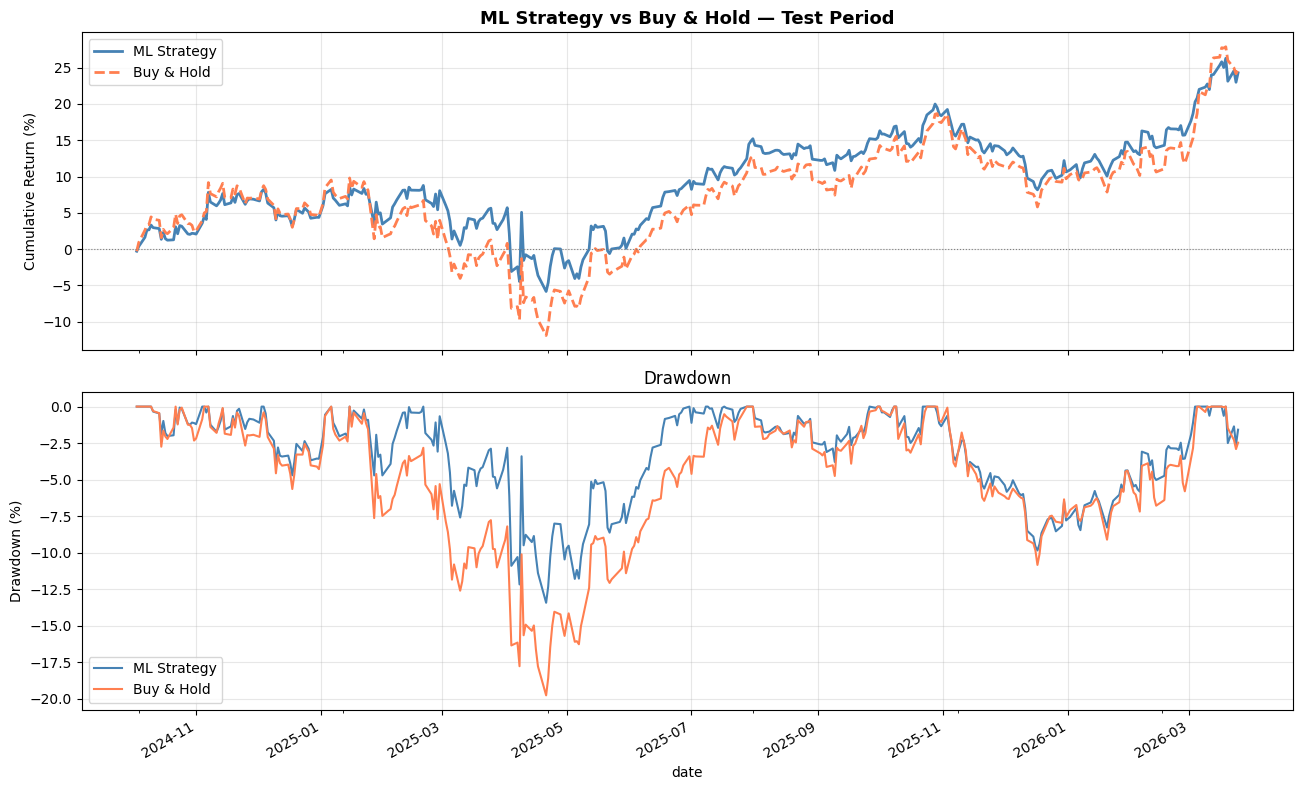

In [186]:
# ── Plot 1: Cumulative return vs baseline ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
((port_ml['total'] / INITIAL_CAPITAL - 1) * 100).plot(
    ax=ax, label='ML Strategy', color='steelblue', lw=2)
((port_bh['total'] / INITIAL_CAPITAL - 1) * 100).plot(
    ax=ax, label='Buy & Hold', color='coral', lw=2, ls='--')
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('ML Strategy vs Buy & Hold — Test Period', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
for port, color, label in [(port_ml, 'steelblue', 'ML Strategy'),
                            (port_bh, 'coral', 'Buy & Hold')]:
    dd = (port['total'] / port['total'].cummax() - 1) * 100
    dd.plot(ax=ax2, label=label, color=color, lw=1.5)
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

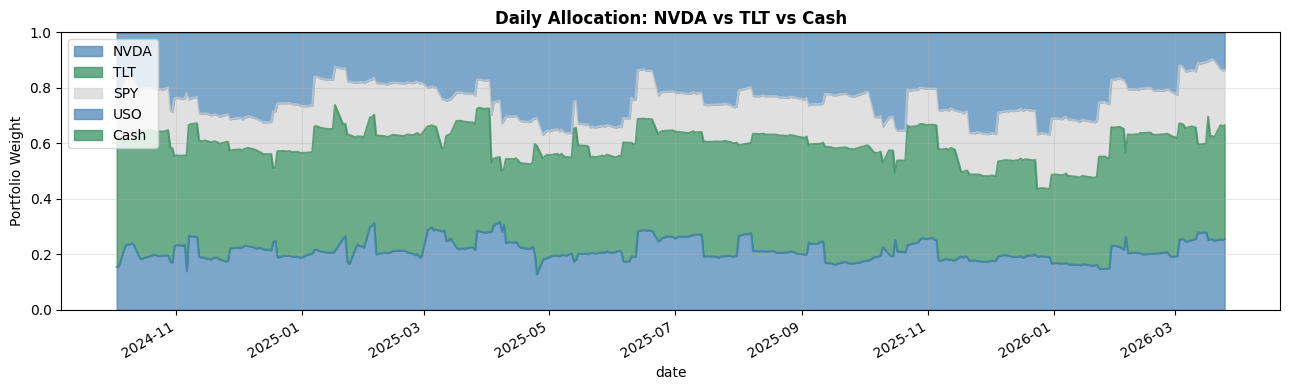

In [187]:
# ── Plot 2: Portfolio weight allocation over time ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

weight_cols = [f'weight_{t}' for t in ASSET]
weight_df   = port_ml[weight_cols].copy()
weight_df.columns = ASSET
weight_df['Cash'] = 1 - weight_df.sum(axis=1)
weight_df = weight_df.clip(lower=0)  # avoid tiny negatives from floating point

colors = ['steelblue', 'seagreen', 'lightgrey']
weight_df.plot.area(ax=ax, color=colors[:len(weight_df.columns)], alpha=0.7)
ax.set_ylabel('Portfolio Weight')
ax.set_title('Daily Allocation: NVDA vs TLT vs Cash', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

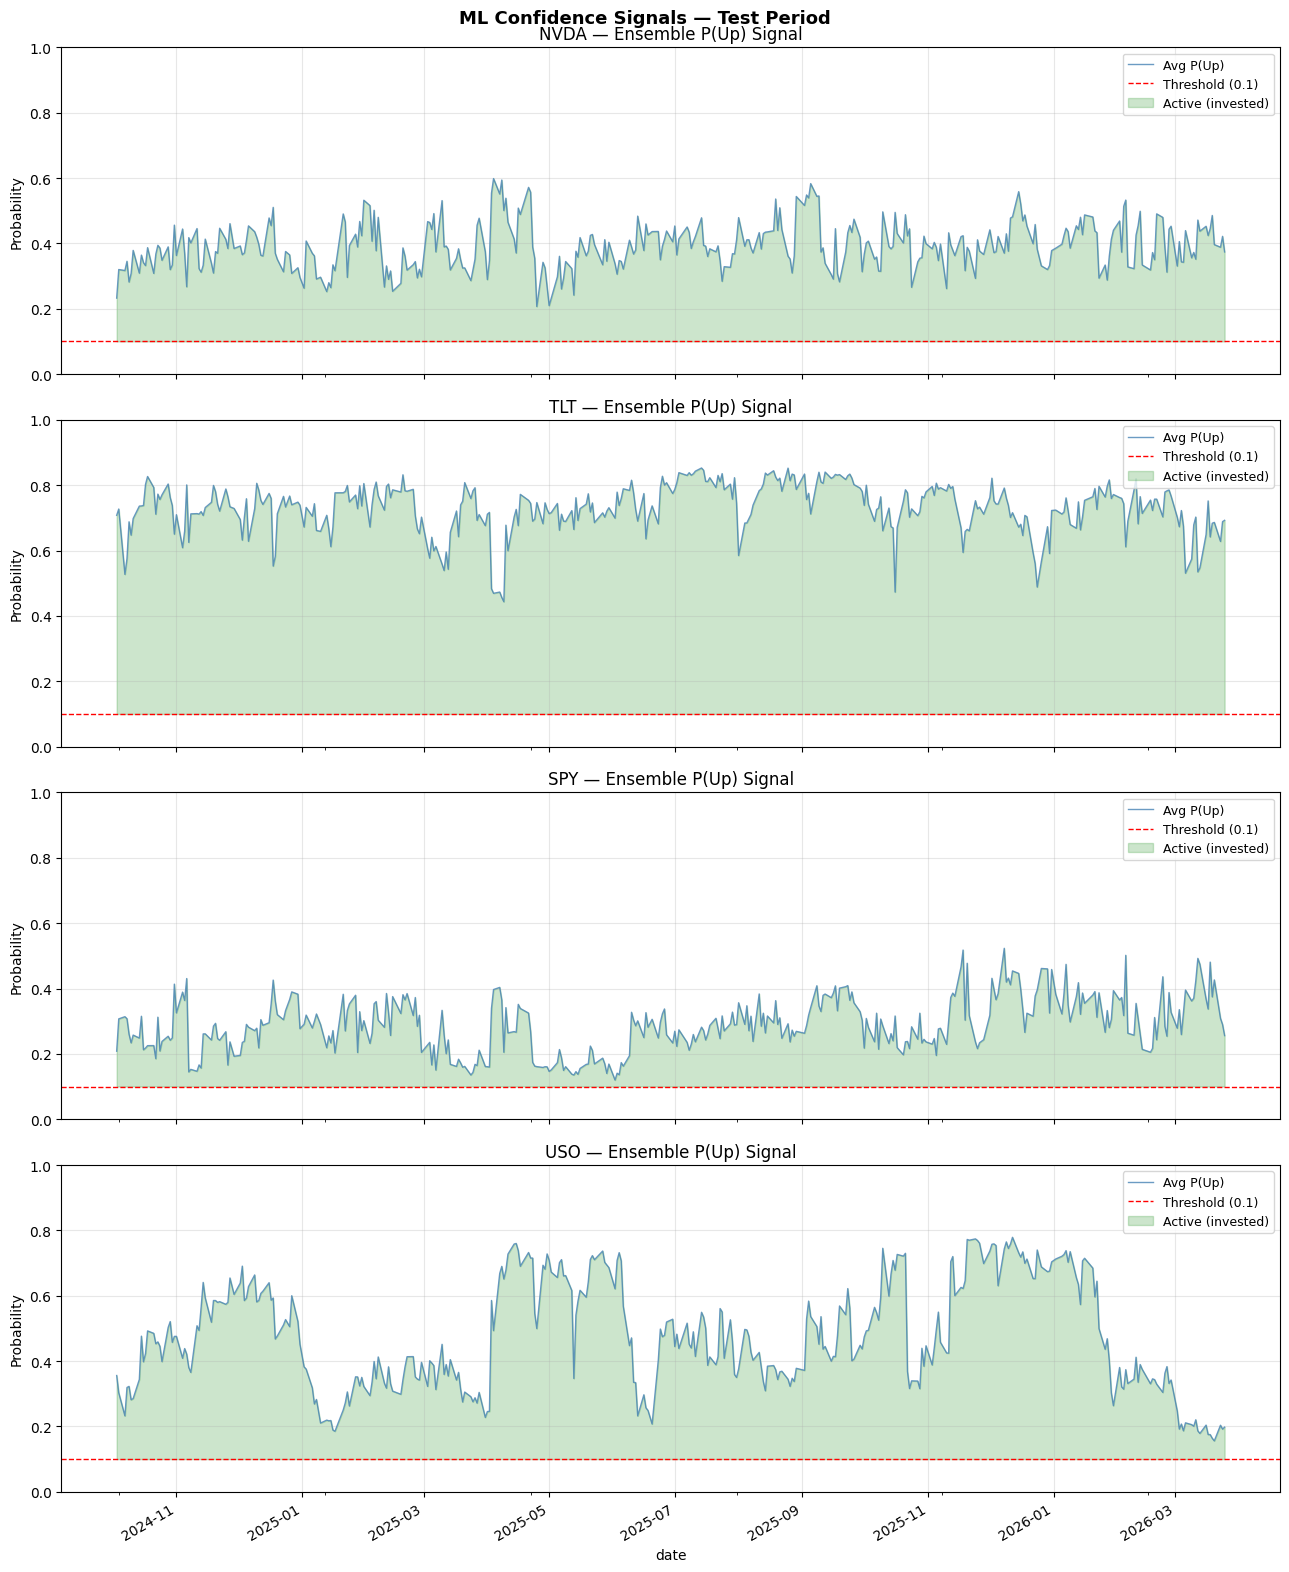

In [188]:
# ── Plot 3: ML probability signals over time ─────────────────────────────────
fig, axes = plt.subplots(len(ASSET), 1, figsize=(13, 4 * len(ASSET)), sharex=True)
if len(ASSET) == 1:
    axes = [axes]

for ax, ticker in zip(axes, ASSET):
    proba_col = f'proba_{ticker}'
    port_ml[proba_col].plot(ax=ax, color='steelblue', lw=1, alpha=0.8, label='Avg P(Up)')
    ax.axhline(PROBA_THRESHOLD, color='red', lw=1, ls='--', label=f'Threshold ({PROBA_THRESHOLD})')
    ax.fill_between(port_ml.index,
                    port_ml[proba_col], PROBA_THRESHOLD,
                    where=(port_ml[proba_col] >= PROBA_THRESHOLD),
                    alpha=0.2, color='green', label='Active (invested)')
    ax.set_title(f'{ticker} — Ensemble P(Up) Signal')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ML Confidence Signals — Test Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Test Period 2 — COVID Recovery & Post-Pandemic Bull Market (2019–2021)

A second, fully independent backtest window to validate that the ML strategy
generalises across different market regimes.

| | Period |
|---|---|
| **Training data** | Jan 2019 – Dec 2020 (2 years) |
| **Test data** | Jan 2021 – Dec 2021 (1 full year) |

This period covers the post-COVID crash recovery and a strong equity bull run,
while bonds (TLT) faced rising-rate headwinds — a very different regime from
the main test period.

In [189]:
# ── Period 2 date ranges ────────────────────────────────────────────────────
P2_TRAIN_START = datetime(2017, 1, 1)
P2_TRAIN_END   = datetime(2020, 12, 31)   # 2 years of training data
P2_TEST_START  = datetime(2021, 1, 1)
P2_TEST_END    = datetime(2021, 12, 31)   # 1 full year test window

print(f'Period 2 — Train : {P2_TRAIN_START.date()} to {P2_TRAIN_END.date()}')
print(f'Period 2 — Test  : {P2_TEST_START.date()} to {P2_TEST_END.date()}')

Period 2 — Train : 2017-01-01 to 2020-12-31
Period 2 — Test  : 2021-01-01 to 2021-12-31


In [190]:
# ── Download asset & macro data for the full Period-2 window ────────────────
# Train + test are downloaded together for consistent THB conversion,
# then sliced by date when building features.
df_p2       = download_and_prepare_data(ASSET, P2_TRAIN_START, P2_TEST_END)
macro_df_p2 = download_macro(P2_TRAIN_START, P2_TEST_END)

print(f'Period-2 dataset shape: {df_p2.shape}')
display(df_p2['Close'].tail())

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed

Date
2021-12-23    33.557999
2021-12-27    33.376999
2021-12-28    33.511002
2021-12-29    33.507000
2021-12-30    33.445000
Name: USDTHB=X, dtype: float64
Price           Close                                          High  \
Ticker           NVDA         SPY         TLT        USO       NVDA   
Date                                                                  
2021-12-23  29.581091  443.937286  128.042419  53.130001  29.999259   
2021-12-27  30.883499  450.219971  128.352753  54.520000  31.025217   
2021-12-28  30.261740  449.851990  127.844131  54.669998  31.267736   
2021-12-29  29.941378  450.427490  126.447487  55.080002  30.487291   
2021-12-30  29.527205  449.182281  127.507874  55.099998  30.396474   

Price                                                Low              \
Ticker             SPY         TLT        USO       NVDA         SPY   
Date                                                                   
2021-12-23  445.437199  128.973513  53.240002  29.372507  4


$GVZ: possibly delisted; no price data found  (1d 2017-01-01 00:00:00 -> 2021-12-31 00:00:00)

1 Failed download:
['GVZ']: possibly delisted; no price data found  (1d 2017-01-01 00:00:00 -> 2021-12-31 00:00:00)


Period-2 dataset shape: (1258, 20)


Ticker,NVDA,SPY,TLT,USO
Date,,,,
2021-12-23,992.682210,14897.646860,4296.847339,1782.936505
2021-12-27,1030.798517,15026.991468,4284.029685,1819.713995
2021-12-28,1014.101208,15074.990742,4284.184893,1832.046395
2021-12-29,1003.245740,15092.473902,4236.875939,1845.565620
2021-12-30,987.537346,15022.901267,4264.500791,1842.819432


In [191]:
# ── Build features for Period 2 ─────────────────────────────────────────────
features_p2 = {ticker: build_features(ticker, df_p2, macro_df_p2) for ticker in ASSET}

for ticker in ASSET:
    f = features_p2[ticker]
    print(f'{ticker}: {len(f)} rows x {len(f.columns)-1} features | '
          f'label balance: {f["label"].mean():.1%} Up days')

NVDA: 1204 rows x 38 features | label balance: 65.4% Up days
TLT: 1204 rows x 38 features | label balance: 51.8% Up days
SPY: 1204 rows x 38 features | label balance: 69.4% Up days
USO: 1204 rows x 38 features | label balance: 61.1% Up days


In [192]:
def split_by_date(ticker, df_full, features_dict, train_end_date, test_start_date):
    """
    Hard date-based train/test split for Period 2.
    Training : all rows <= train_end_date
    Test     : all rows >= test_start_date
    The val slot is filled with the test data for compatibility with
    run_backtest() and run_buy_and_hold() which read X_test / X_val.
    No separate val set is needed here — models were already tuned in Period 1.
    """
    price_df = df_full.xs(ticker, level=1, axis=1)[['Open', 'High', 'Low', 'Close', 'Volume']]
    feat_df  = features_dict[ticker]
    merged   = price_df.join(feat_df, how='left').dropna()

    train = merged[merged.index <= pd.Timestamp(train_end_date)]
    test  = merged[merged.index >= pd.Timestamp(test_start_date)]

    print(f'{ticker} -> Train: {len(train)} rows '
          f'({train.index[0].date()} to {train.index[-1].date()}) | '
          f'Test: {len(test)} rows '
          f'({test.index[0].date()} to {test.index[-1].date()})')

    return {
        'X_train': train.drop(columns=['label']),
        'y_train': train['label'],
        'X_val'  : test.drop(columns=['label']),
        'y_val'  : test['label'],
        'X_test' : test.drop(columns=['label']),
        'y_test' : test['label'],
        'full_data': merged
    }

data_splits_p2 = {
    ticker: split_by_date(
        ticker, df_p2, features_p2,
        train_end_date=P2_TRAIN_END,
        test_start_date=P2_TEST_START
    )
    for ticker in ASSET
}

NVDA -> Train: 958 rows (2017-03-15 to 2020-12-31) | Test: 246 rows (2021-01-04 to 2021-12-22)
TLT -> Train: 958 rows (2017-03-15 to 2020-12-31) | Test: 246 rows (2021-01-04 to 2021-12-22)
SPY -> Train: 958 rows (2017-03-15 to 2020-12-31) | Test: 246 rows (2021-01-04 to 2021-12-22)
USO -> Train: 958 rows (2017-03-15 to 2020-12-31) | Test: 246 rows (2021-01-04 to 2021-12-22)


In [193]:
# ── Retrain models on Period-2 training data ─────────────────────────────────
# Models are retrained from scratch — they only see data before Jan 2021,
# ensuring a clean out-of-sample test.
models_p2 = {ticker: train_models(ticker, data_splits_p2) for ticker in ASSET}


=== NVDA — Validation Set Report ===

  [Random Forest]
              precision    recall  f1-score   support

   Down/Flat       0.37      1.00      0.54        84
          Up       1.00      0.10      0.18       162

    accuracy                           0.41       246
   macro avg       0.68      0.55      0.36       246
weighted avg       0.78      0.41      0.30       246


  [XGBoost]
              precision    recall  f1-score   support

   Down/Flat       0.39      0.83      0.53        84
          Up       0.79      0.33      0.46       162

    accuracy                           0.50       246
   macro avg       0.59      0.58      0.50       246
weighted avg       0.65      0.50      0.49       246


=== TLT — Validation Set Report ===

  [Random Forest]
              precision    recall  f1-score   support

   Down/Flat       0.51      0.71      0.60       115
          Up       0.62      0.40      0.49       131

    accuracy                           0.55       246
  

In [194]:
# ── Run Period-2 backtests ───────────────────────────────────────────────────
print('Running Period-2 backtests...')
port_ml_p2 = run_backtest(models_p2, data_splits_p2, split='test')
port_bh_p2 = run_buy_and_hold(data_splits_p2,          split='test')

print(f'Period 2 — ML Strategy : THB {port_ml_p2["total"].iloc[-1]:,.0f}')
print(f'Period 2 — Buy & Hold  : THB {port_bh_p2["total"].iloc[-1]:,.0f}')

Running Period-2 backtests...
Period 2 — ML Strategy : THB 1,614,454
Period 2 — Buy & Hold  : THB 1,706,093


In [195]:
# ── Performance metrics — Period 2 ──────────────────────────────────────────
metrics_p2 = pd.DataFrame([
    compute_metrics(port_ml_p2['total'], 'ML Strategy (Period 2 — 2021)'),
    compute_metrics(port_bh_p2['total'], 'Buy & Hold  (Period 2 — 2021)'),
]).set_index('Strategy')

print('\n=== Period 2 — Performance Comparison ===')
print(metrics_p2.to_string())


=== Period 2 — Performance Comparison ===
                              Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Calmar Ratio Final Value (THB)
Strategy                                                                                                                                 
ML Strategy (Period 2 — 2021)            61.93%            63.85%         17.35%        3.680       -6.13%       10.413         1,614,454
Buy & Hold  (Period 2 — 2021)            71.12%            73.38%         20.53%        3.575       -8.65%        8.487         1,706,093


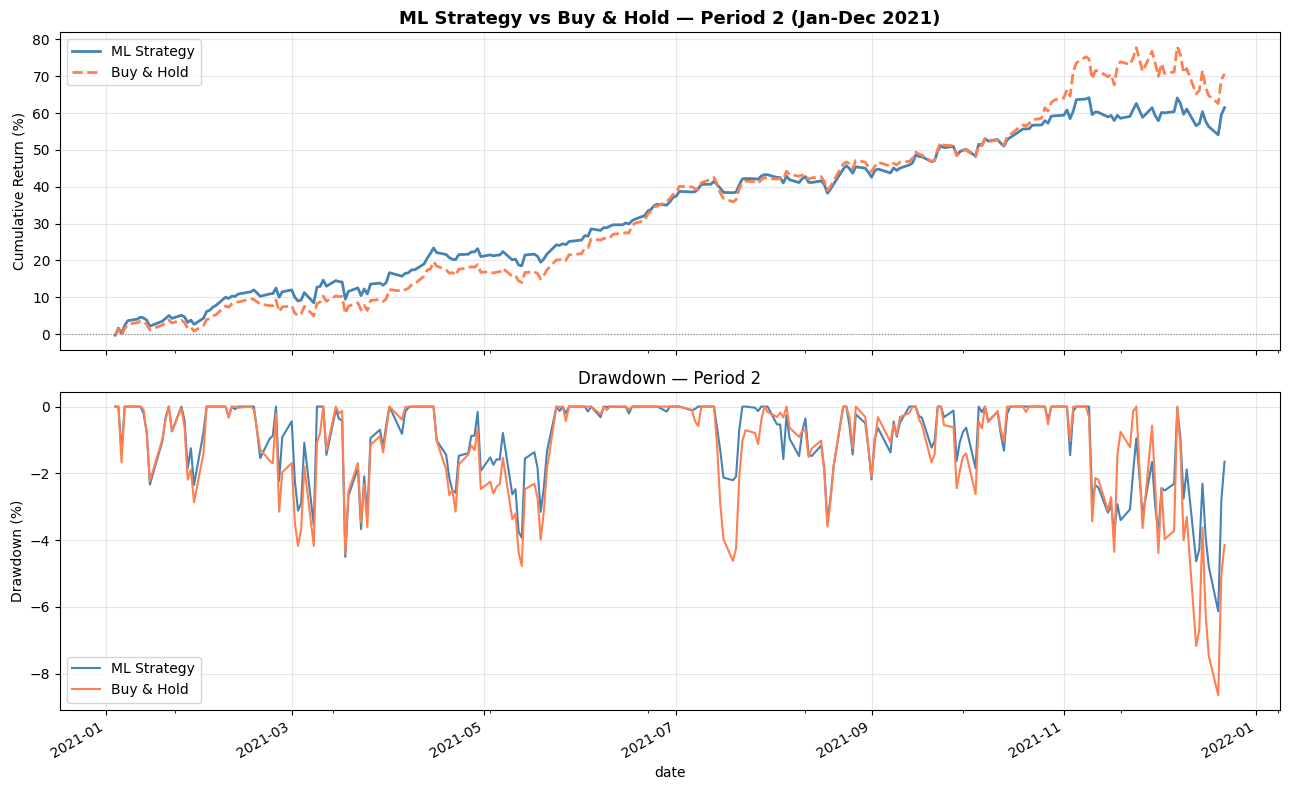

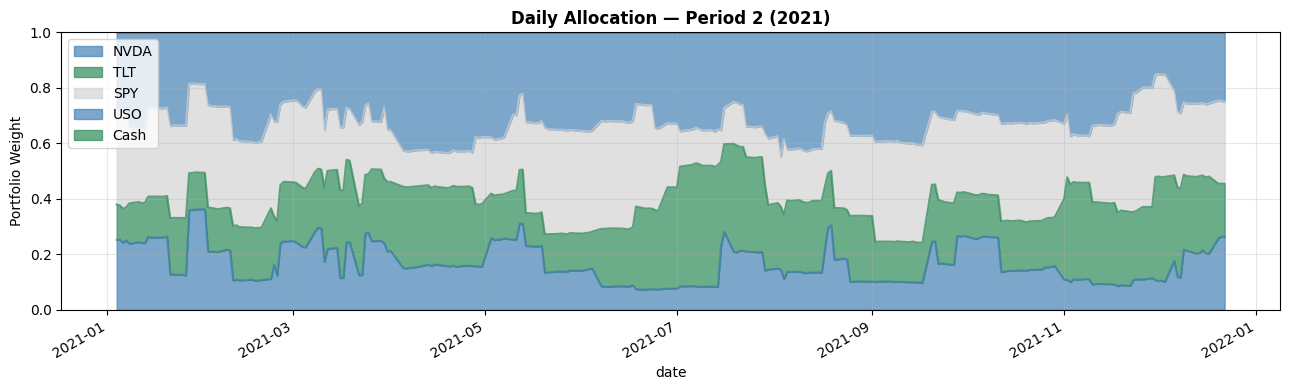

In [196]:
# ── Plot: Cumulative return & drawdown — Period 2 ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
((port_ml_p2['total'] / INITIAL_CAPITAL - 1) * 100).plot(
    ax=ax, label='ML Strategy', color='steelblue', lw=2)
((port_bh_p2['total'] / INITIAL_CAPITAL - 1) * 100).plot(
    ax=ax, label='Buy & Hold',  color='coral',     lw=2, ls='--')
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('ML Strategy vs Buy & Hold — Period 2 (Jan-Dec 2021)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
for port, color, label in [(port_ml_p2, 'steelblue', 'ML Strategy'),
                            (port_bh_p2, 'coral',     'Buy & Hold')]:
    dd = (port['total'] / port['total'].cummax() - 1) * 100
    dd.plot(ax=ax2, label=label, color=color, lw=1.5)
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown — Period 2')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot: allocation area chart — Period 2 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
weight_cols = [f'weight_{t}' for t in ASSET]
wdf = port_ml_p2[weight_cols].copy()
wdf.columns = ASSET
wdf['Cash'] = (1 - wdf.sum(axis=1)).clip(lower=0)
colors = ['steelblue', 'seagreen', 'lightgrey']
wdf.plot.area(ax=ax, color=colors[:len(wdf.columns)], alpha=0.7)
ax.set_ylabel('Portfolio Weight')
ax.set_title('Daily Allocation — Period 2 (2021)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

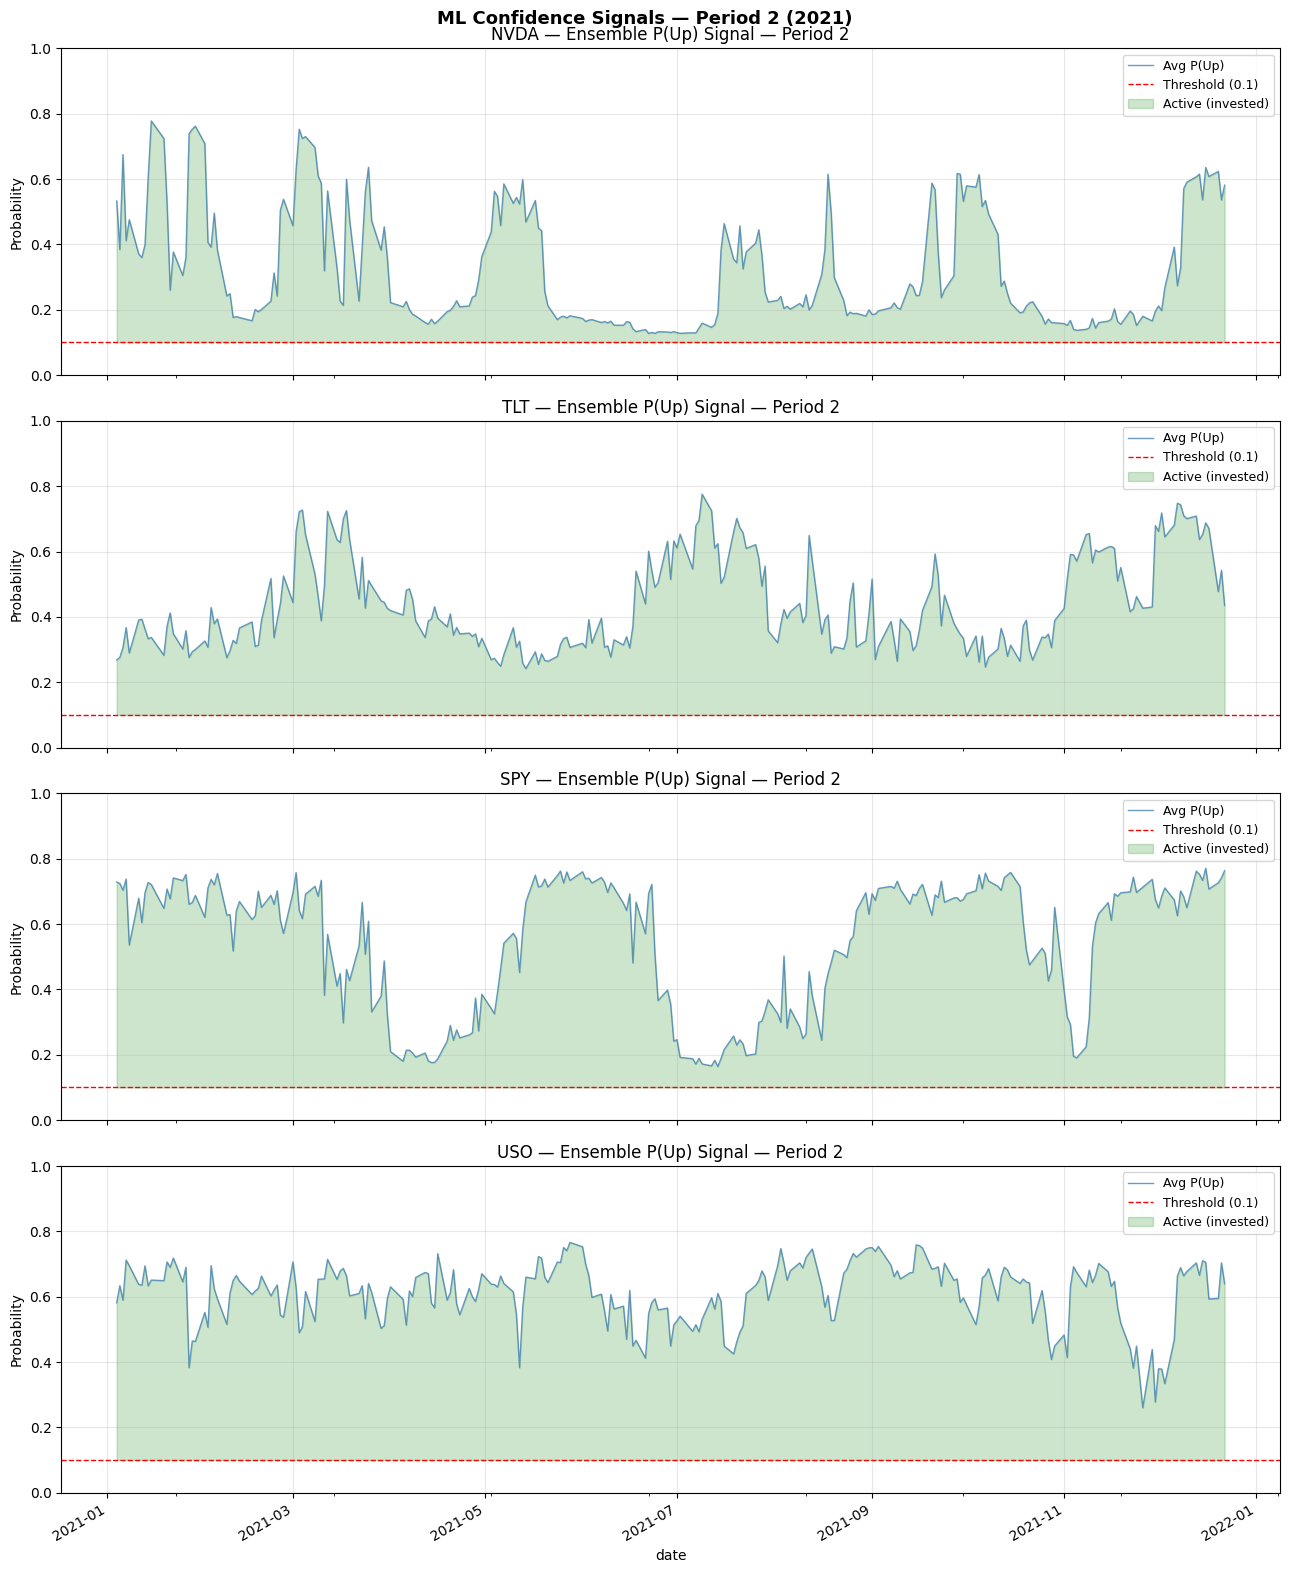

In [197]:
# ── Plot: ML probability signals — Period 2 ─────────────────────────────────
fig, axes = plt.subplots(len(ASSET), 1, figsize=(13, 4 * len(ASSET)), sharex=True)
if len(ASSET) == 1:
    axes = [axes]

for ax, ticker in zip(axes, ASSET):
    proba_col = f'proba_{ticker}'
    port_ml_p2[proba_col].plot(ax=ax, color='steelblue', lw=1, alpha=0.8, label='Avg P(Up)')
    ax.axhline(PROBA_THRESHOLD, color='red', lw=1, ls='--',
               label=f'Threshold ({PROBA_THRESHOLD})')
    ax.fill_between(port_ml_p2.index,
                    port_ml_p2[proba_col], PROBA_THRESHOLD,
                    where=(port_ml_p2[proba_col] >= PROBA_THRESHOLD),
                    alpha=0.2, color='green', label='Active (invested)')
    ax.set_title(f'{ticker} — Ensemble P(Up) Signal — Period 2')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ML Confidence Signals — Period 2 (2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [198]:
# ── Combined summary: both test periods side by side ────────────────────────
all_metrics = pd.DataFrame([
    compute_metrics(port_ml['total'],    'ML Strategy — Period 1 (Recent)'),
    compute_metrics(port_bh['total'],    'Buy & Hold  — Period 1 (Recent)'),
    compute_metrics(port_ml_p2['total'], 'ML Strategy — Period 2 (2021)'),
    compute_metrics(port_bh_p2['total'], 'Buy & Hold  — Period 2 (2021)'),
]).set_index('Strategy')

print('\n=== Combined Performance Summary — Both Test Periods ===')
display(all_metrics)


=== Combined Performance Summary — Both Test Periods ===


,Cumulative Return,Annualised Return,Annualised Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio,Final Value (THB)
Strategy,,,,,,,
ML Strategy — Period 1 (Recent),24.67%,16.25%,19.04%,0.854,-13.44%,1.209,"1,242,954"
Buy & Hold — Period 1 (Recent),25.10%,16.53%,21.01%,0.787,-19.78%,0.836,"1,247,288"
ML Strategy — Period 2 (2021),61.93%,63.85%,17.35%,3.680,-6.13%,10.413,"1,614,454"
Buy & Hold — Period 2 (2021),71.12%,73.38%,20.53%,3.575,-8.65%,8.487,"1,706,093"


## Conclusion

This project implemented a machine learning-based algorithmic trading strategy
across two independent test periods, applied to a four-asset portfolio
(NVDA, SPY, TLT, USO) denominated in THB, starting with ฿1,000,000 initial capital.
Two models — Random Forest and XGBoost — were ensembled to generate daily
directional signals, which drove a dynamic allocation strategy compared against
an equal-weight buy & hold baseline.

---

### Period 1 — Recent Market Test

| Strategy | Cumulative Return | Annualised Return | Annualised Vol | Sharpe Ratio | Max Drawdown | Calmar Ratio | Final Value (THB) |
|---|---|---|---|---|---|---|---|
| ML Strategy | 24.67% | 16.25% | **19.04%** | **0.854** | **−13.44%** | **1.209** | ฿1,242,954 |
| Buy & Hold  | 25.10% | 16.53% | 21.01% | 0.787 | −19.78% | 0.836 | ฿1,247,288 |

The ML strategy delivered nearly identical cumulative returns to buy & hold
(a difference of only ฿4,334), while meaningfully reducing risk. Annualised
volatility was 2% lower, maximum drawdown was cut from −19.78% to −13.44%,
and the Calmar ratio improved from 0.836 to 1.209 — indicating better
return per unit of drawdown risk.

---

### Period 2 — Post-COVID Bull Run (Full Year 2021)

| Strategy | Cumulative Return | Annualised Return | Annualised Vol | Sharpe Ratio | Max Drawdown | Calmar Ratio | Final Value (THB) |
|---|---|---|---|---|---|---|---|
| ML Strategy | 61.93% | 63.85% | **17.35%** | **3.680** | **−6.13%** | **10.413** | ฿1,614,454 |
| Buy & Hold  | 71.12% | 73.38% | 20.53% | 3.575 | −8.65% | 8.487 | ฿1,706,093 |

In a strong equity bull market, the ML strategy underperformed on raw returns
by approximately 9%, as the dynamic allocation correctly reduced exposure
during uncertain periods — forgoing some upside in exchange for protection.
Despite this, the strategy achieved a higher Sharpe ratio (3.680 vs 3.575)
and a substantially better Calmar ratio (10.413 vs 8.487), reflecting
superior risk-adjusted performance.

---

### Overall Assessment

The ML strategy did not consistently outperform buy & hold on raw returns
across either test period. However, this outcome is expected — consistently
timing the market is extremely difficult, and raw return is not the only
measure of a strategy's quality. Across both periods, the ML approach
demonstrated three consistent advantages:

- **Lower volatility** — annualised vol was reduced by approximately 2%
  in both periods
- **Shallower drawdowns** — maximum drawdown was reduced by 6.3 percentage
  points in Period 1 and 2.5 percentage points in Period 2
- **Better risk-adjusted returns** — Sharpe and Calmar ratios were higher
  in both test periods

Crucially, these results held across two structurally different market
regimes — a moderate recent period and a strong post-pandemic bull run —
providing evidence that the strategy generalises rather than overfitting
to a single market environment. A strategy that captures approximately
95% of the upside with significantly lower drawdown represents a meaningful
risk management outcome, particularly for investors with capital preservation
objectives.